# Notebook 01: Data Exploration & Quality Audit

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

In [2]:
import duckdb
import yaml
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [3]:
DB_PATH = "../data/warehouse.duckdb"

In [4]:
with duckdb.connect(DB_PATH) as con:
    tables = con.execute("""
        SELECT table_name
        FROM information_schema.tables
        WHERE table_schema = 'bronze';
    """).df().table_name.values

## Data Integrity & Schema Audit

### Schema Check

In [5]:
for t_name in tables:
    with duckdb.connect(DB_PATH) as con:
        print(f"--- Profiling Schema: {t_name} ---\n")
        print(con.execute(f"""
            SELECT 
                CASE WHEN LENGTH(column_name) > 28
                    THEN SUBSTR(column_name, 1, 25) || '...'
                    ELSE column_name
                END AS column_name,
                data_type
            FROM information_schema.columns
            WHERE table_name = '{t_name}'
            AND table_schema = 'bronze';
        """).df())
        print()

--- Profiling Schema: job_postings_raw ---

     column_name  data_type
0       job_hash    VARCHAR
1      adzuna_id    VARCHAR
2          title    VARCHAR
3        company    VARCHAR
4     created_at  TIMESTAMP
5       category    VARCHAR
6       location    VARCHAR
7    description    VARCHAR
8       noc_code    VARCHAR
9    search_term    VARCHAR
10   ingested_at  TIMESTAMP
11        source    VARCHAR
12  redirect_url    VARCHAR

--- Profiling Schema: sc_graduates_raw ---

                    column_name  data_type
0                     Geography    VARCHAR
1  International Standard Cl...    VARCHAR
2                Field of study    VARCHAR
3              Institution type    VARCHAR
4                        Gender    VARCHAR
5                      REF_DATE    VARCHAR
6                         VALUE     DOUBLE
7                           pid    VARCHAR
8                   ingested_at  TIMESTAMP
9                        source    VARCHAR

--- Profiling Schema: sc_income_2021_raw ---


### Null-Value Profiling

In [6]:
def count_nulls(tables):
    counts = None
    with duckdb.connect(DB_PATH) as con:
        for t_name in tables:
            target_col = "VALUE" if t_name.startswith("sc_") else "description"
            df = con.execute(f"""
                SELECT
                    '{t_name}' AS table_name,
                    COUNT(*) AS total_rows,
                    SUM(CASE WHEN "{target_col}" IS NULL THEN 1 ELSE 0 END) AS nulls_count,
                    ROUND(100.0 * SUM(CASE WHEN "{target_col}" IS NULL THEN 1 ELSE 0 END) / COUNT(*), 2) AS null_pct
                FROM bronze.{t_name};
            """).df()
            counts = pd.concat([counts, df])
        print(counts)

In [7]:
count_nulls(tables)

            table_name  total_rows  nulls_count  null_pct
0     job_postings_raw        1558          0.0      0.00
0     sc_graduates_raw          84          0.0      0.00
0   sc_income_2021_raw          44          2.0      4.55
0  sc_labour_force_raw          48          0.0      0.00
0      sc_lfs_2021_raw         129          0.0      0.00
0         sc_wages_raw          16          0.0      0.00


### Job Description Truncation Audit

In [8]:
with duckdb.connect(DB_PATH) as con:
    print(con.execute(f"""
        SELECT
            MIN(LENGTH(description)) AS min_text_len,
            AVG(LENGTH(description)) AS avg_text_len,
            MAX(LENGTH(description)) AS max_text_len
        FROM bronze.job_postings_raw;
    """).df().round(2))

   min_text_len  avg_text_len  max_text_len
0           500       5451.18         19112


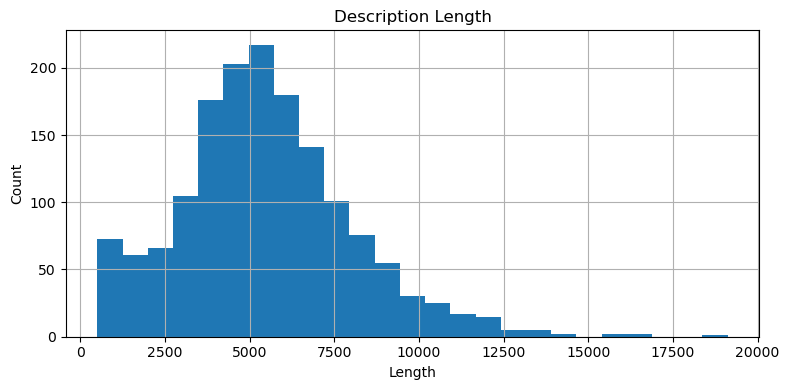

In [9]:
with duckdb.connect(DB_PATH) as con:
    con.execute(f"""
        SELECT LENGTH(description) as text_length
        FROM bronze.job_postings_raw;
    """).df().round(2).hist(bins=25, figsize=(8,4))
    plt.title("Description Length")
    plt.xlabel("Length")
    plt.ylabel("Count")
    plt.tight_layout()

## 2. Labor Market Distribution

In [10]:
with duckdb.connect(DB_PATH) as con:
    job_counts = con.execute("""
        SELECT
            noc_code,
            search_term,
            COUNT(*) AS num_postings
        FROM bronze.job_postings_raw
        GROUP BY noc_code, search_term;
    """).df()

In [11]:
noc_counts = (job_counts
                  .groupby("noc_code")["num_postings"]
                  .sum()
                  .sort_values(ascending=False))
(noc_counts / noc_counts.sum()).mul(100).round(2)

noc_code
21211    28.18
21232    22.72
21231    15.79
21221     9.18
21223     8.66
21234     8.60
21220     6.87
Name: num_postings, dtype: float64

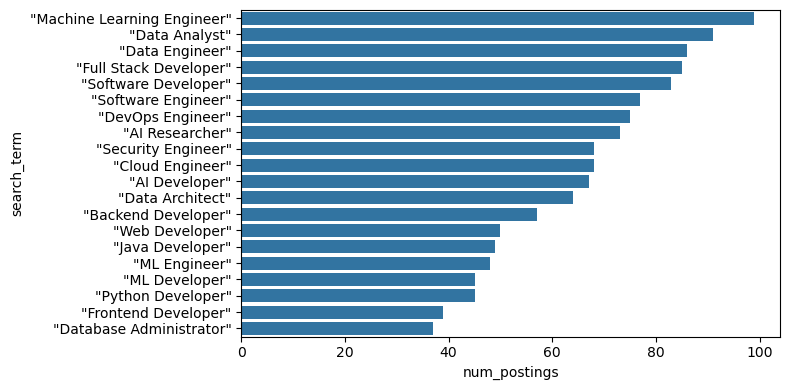

In [12]:
plt.figure(figsize=(8,4))
sns.barplot(
    job_counts.sort_values(by="num_postings", ascending=False).head(20), 
    x="num_postings", y="search_term"
)
plt.tight_layout()
plt.show()

## 2. Data Preprocessing Prototyping

### NOC Alignment & Taxonomy Consolidation

The [2021 National Occupational Classification (NOC)](https://noc.esdc.gc.ca/Structure/Hierarchy) provides a granular breakdown of technical roles. To optimize our SkillPath-Engine, we would map our scraped titles to the following core units:
- **21210 (Math & Stats):** Develops and applies mathematical or statistical techniques to solve complex problems and assess financial risk.
- **21211 (Data Science):** Uses advanced analytics, machine learning, and predictive modeling to extract insights from unstructured data.
- **21220 (Cybersecurity):** Plans and implements security measures to protect networks, devices, and organizational information.
- **21221 (Business Systems):** Translates corporate strategic objectives into technical IT architectures and tasks.
- **21222 (Information Systems):** Analyzes and assesses system requirements while implementing information development plans and policies.
- **21223 (Database & Data Admin):** Designs, develops, and administers data management solutions and administration standards.
- **21230 (Systems Programming):** Writes and tests code for software applications, operating systems, and communications software.
- **21231 (Software Engineering):** Researches and designs technical environments, embedded software, and information warehouses.
- **21232 (Software Development):** Designs and writes code for new systems to ensure overall efficiency and effectiveness.
- **21233 (Web Design):** Develops the visual layout, presentation, and user-interface functionality of websites.
- **21234 (Web Development):** Uses programming languages to create, modify, and integrate website capacity and performance.

### Job Titles Mapping

In [14]:
from src.transformation.role_mapper import map_roles

In [15]:
with duckdb.connect(DB_PATH) as con:
    job_headers = con.execute("""
        SELECT noc_code, search_term, title
        FROM bronze.job_postings_raw;
    """).df()

In [16]:
audited_noc = map_roles(job_headers, yaml_path="../config/role_mapping.yaml", full_report=True)

Initializing Semantic Model...
Mapping 1558 roles...


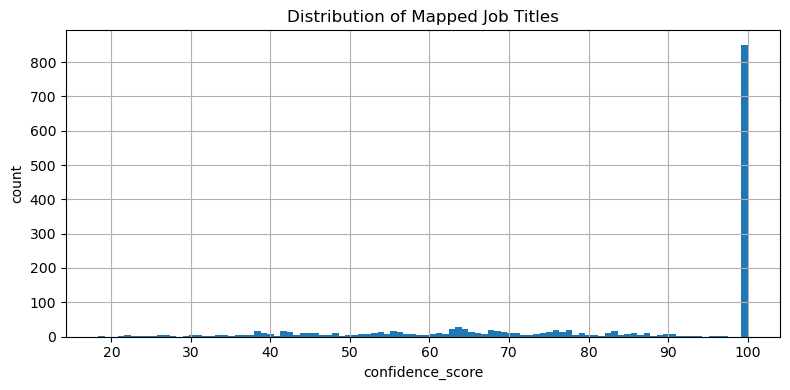

In [48]:
audited_noc["confidence_score"].hist(bins=100, figsize=(8,4))
plt.title("Distribution of Mapped Job Titles")
plt.xlabel("confidence_score")
plt.ylabel("count")
plt.tight_layout()

In [22]:
from scipy.interpolate import make_interp_spline, UnivariateSpline

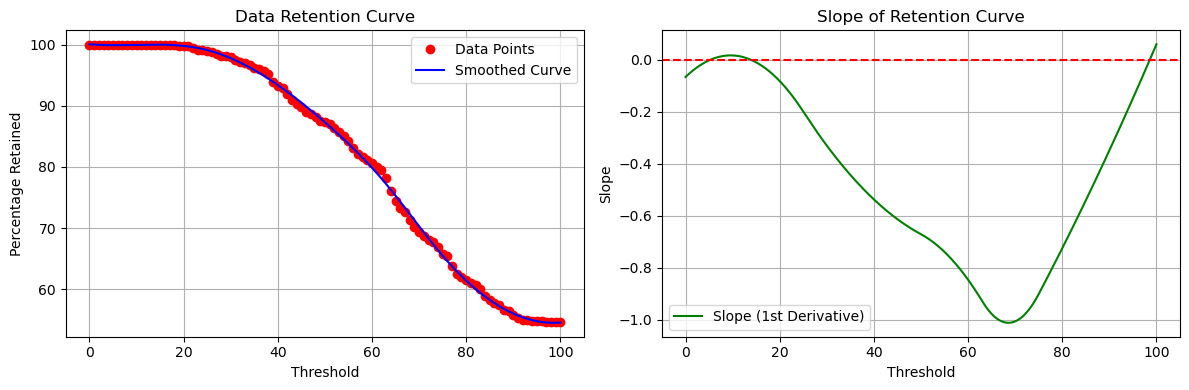

In [35]:
spline = UnivariateSpline(thresholds, percentages, s=20)
x_smooth = np.linspace(thresholds.min(), thresholds.max(), 500)
y_smooth = spline(x_smooth)
y_der = spline.derivative()(x_smooth)

# Plotting to verify
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(thresholds, percentages, 'ro', label='Data Points')
plt.plot(x_smooth, y_smooth, 'b-', label='Smoothed Curve')
plt.title('Data Retention Curve')
plt.xlabel('Threshold')
plt.ylabel('Percentage Retained')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x_smooth, y_der, 'g-', label='Slope (1st Derivative)')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Slope of Retention Curve')
plt.xlabel('Threshold')
plt.ylabel('Slope')
plt.legend()
plt.grid(True)

plt.tight_layout()

In [45]:
steepest_idx = np.argmin(y_der)
steepest_threshold = x_smooth[steepest_idx]
print(f"The Steepest Point (cliff): {steepest_threshold:.2f}")

The Steepest Point (cliff): 68.54


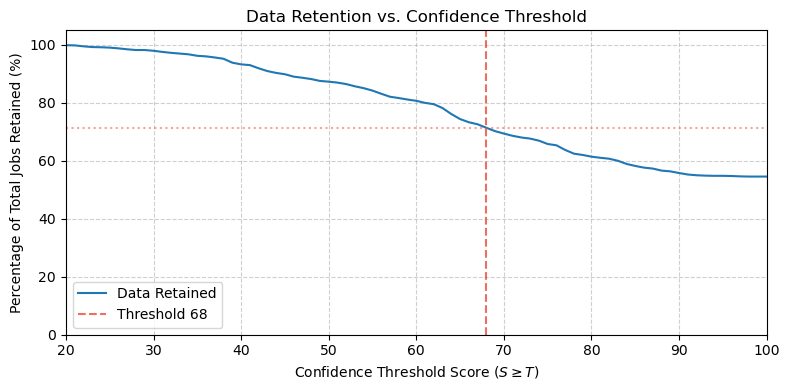

In [55]:
thresholds = np.arange(0, 101, 1)
percentages = []

for t in thresholds:
    mask = audited_noc['confidence_score'] >= t
    pct = 100 * len(audited_noc[mask]) / len(audited_noc)
    percentages.append(pct)

plt.figure(figsize=(8, 4))
plt.plot(thresholds, percentages, label='Data Retained')

# Highlight the "Recommended Threshold"
RECOMMENDED_T = int(np.floor(steepest_threshold))
retention_at_65 = percentages[RECOMMENDED_T]

plt.axvline(x=RECOMMENDED_T, color='#e74c3c', linestyle='--', alpha=0.8, label=f'Threshold {RECOMMENDED_T}')
plt.axhline(y=retention_at_65, color='#e74c3c', linestyle=':', alpha=0.5)

plt.title("Data Retention vs. Confidence Threshold")
plt.xlabel("Confidence Threshold Score ($S \geq T$)")
plt.ylabel("Percentage of Total Jobs Retained (%)")

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower left')
plt.ylim(0, 105)
plt.xlim(20, 100)

plt.tight_layout()
plt.show()

In [53]:
print(f"~%{percentages[68]:.1f} of data is retained with a threshold of 68.54")

~%71.4 of data is retained with a threshold of 68.54


In [43]:
audited_noc[audited_noc["confidence_score"].between(68.54, 69)].sample(frac=1.0).head(10)

,noc_code,search_term,title,clean_title,matched_label,confidence_score,assigned_noc,match_method
163,21211,"""ML Engineer""","Engineering Manager, AI","engineer manager, ai",AI Developer,68.77,21211,Semantic
1286,21232,"""C# Developer""",.NET Cloud Developer,net cloud developer,Cloud Engineer,68.90,21231,Semantic
258,21211,"""AI Developer""",Staff Developer Advocacy Engineer | Canada | R...,developer advocacy engineer,Software Developer,68.56,21232,Semantic
169,21211,"""ML Engineer""","Engineering Manager, AI Applications","engineer manager, ai applications",AI Developer,68.77,21211,Semantic
1346,21220,"""Security Engineer""",Senior IAM Systems Engineer (Global Security),iam systems engineer global security,Security Engineer,68.96,21220,Semantic
832,21231,"""DevOps Engineer""",Staff Infrastructure Engineer,infrastructure engineer,Security Engineer,69.00,21220,Semantic
935,21231,"""Cloud Engineer""",Windows Desktop Developer (Hybrid),windows desktop developer,C# Developer,68.64,21232,Semantic
60,21211,"""Machine Learning Engineer""",Director ML Platform Engineering,director ml platform engineer,ML Developer,68.61,21211,Semantic


With a threshold of 68.54, the mapping of job titles is quite effective.

### Table Transformations

In [ ]:
def transform_table(con, table_name, pivot_cols=None, val_col="VALUE", keeps=["ingested_at", "source"], limit=None):
    df = con.execute(f"SELECT * FROM bronze.{table_name}" + (f" LIMIT {limit}" if limit else "") + ";").df()
    constant_cols = [col for col in df.columns if df[col].nunique() <= 1 and col not in keeps]
    df = df.drop(columns=constant_cols)

    if pivot_cols:
        pivot_idx = [c for c in df.columns if c not in pivot_cols and c != val_col]
        df_wide = df.pivot(index=pivot_idx, columns=pivot_cols, values=val_col).reset_index()
        df_wide.columns.name = None
        return df_wide
    return df

In [ ]:
EDUCATION_MAP = {
    "Bachelor's or equivalent": "Bachelor's degree",
    "Master's or equivalent": "Master's degree",
    "Doctoral or equivalent": "Doctoral degree",
    "Earned doctorate": "Doctoral degree",
    "College, CEGEP or other non-university certificate or diploma": "CEGEP/College",
    "Computer and information sciences and support services": "Computer science"
}

In [ ]:
def _base_statcan_preprocess(table_name, rename_map, keeps, pivot_cols=None, limit=None):
    with duckdb.connect(db_path) as con:
        df = transform_table(
            con, 
            table_name=table_name, 
            pivot_cols=pivot_cols, 
            keeps=keeps, 
            limit=limit
        )
        
        # Standardize Columns
        df = df.rename(columns=rename_map)
        
        # Standardize Values (Education/Fields)
        df = df.replace(EDUCATION_MAP)
        
        # Standardize NOC Occupations (Remove leading codes like '21211 ')
        if "occupation" in df.columns:
            df["occupation"] = df["occupation"].str.replace(r"^\d+ ", "", regex=True)
            
        return df

In [ ]:
def preprocess_graduates(limit):
    return base_preprocess(
        table_name="annual_graduates_raw",
        keeps=["Geography"],
        limit=limit,
        rename_map={
            "International Standard Classification of Education (ISCED)": "education_level",
            "Field of study": "field_of_study",
            "REF_DATE": "date",
            "VALUE": "graduates"
        }
    )

In [ ]:
def preprocess_census_income(limit):
    return base_preprocess(
        table_name="census_income_2021_raw",
        keeps=["Geography", "REF_DATE", "Highest certificate, diploma or degree (16)", 
                "Occupation - Unit group - National Occupational Classification (NOC) 2021 (821A)"],
        limit=limit,
        rename_map={
            "Occupation - Unit group - National Occupational Classification (NOC) 2021 (821A)": "occupation",
            "Highest certificate, diploma or degree (16)": "education_level",
            "REF_DATE": "date",
            "VALUE": "median_income"
        }
    )

In [ ]:
def preprocess_income_ts(limit):
    df = base_preprocess(
        table_name="annual_wages_raw",
        keeps=["Geography", "REF_DATE", "National Occupational Classification (NOC)"],
        limit=limit,
        rename_map={
            "National Occupational Classification (NOC)": "occupation",
            "REF_DATE": "date",
            "VALUE": "weekly_wages"
        }
    )
    df["median_income"] = df["weekly_wages"] * 4 * 12
    return df

## 1. Data Integrity Check

### Check Row Counts & Table Existence

In [5]:
with duckdb.connect(db_path) as con:
    tables = con.execute("""
        SELECT
           table_schema,
           table_name
        FROM information_schema.tables
        WHERE table_schema = 'bronze';
    """).df()
    print(tables)

  table_schema           table_name
0       bronze     job_postings_raw
1       bronze     sc_graduates_raw
2       bronze   sc_income_2021_raw
3       bronze  sc_labour_force_raw
4       bronze      sc_lfs_2021_raw
5       bronze         sc_wages_raw


### Null Profilling

In [15]:
def count_sc_nulls(table_names):
    counts = None
    for t_name in table_names:
        if not t_name.startswith("sc_"):
            continue
    
        with duckdb.connect(db_path) as con:
            df = con.execute(f"""
                SELECT
                    COUNT(*) AS total_rows,
                    SUM(
                        CASE WHEN "VALUE" IS NULL 
                        THEN 1 ELSE 0 
                        END) AS null_counts,
                    ROUND(100.0 * SUM(
                            CASE WHEN "VALUE" IS NULL 
                            THEN 1 ELSE 0 
                            END) / COUNT(*), 2) AS null_percentage
                FROM bronze.{t_name};
            """).df()
            df["table_name"] = t_name
            counts = pd.concat([counts, df])
    
    print(counts.set_index("table_name"))

count_sc_nulls(tables["table_name"])

                     total_rows  null_counts  null_percentage
table_name                                                   
sc_graduates_raw             30          0.0             0.00
sc_income_2021_raw           44          2.0             4.55
sc_labour_force_raw          15          0.0             0.00
sc_lfs_2021_raw             129          0.0             0.00
sc_wages_raw                  5          0.0             0.00


In [17]:
with duckdb.connect(db_path) as con:
    print(con.execute("""
        SELECT
            COUNT(*) AS total_rows,
            SUM(CASE WHEN description IS NULL
                THEN 1 ELSE 0 
                END) as null_descriptions,
            SUM(CASE WHEN company IS NULL
                THEN 1 ELSE 0
                END) as null_companies
        FROM bronze.job_postings_raw
    """).df())

   total_rows  null_descriptions  null_companies
0        1558                0.0             2.0


## 2. Data Distribution

In [38]:
with duckdb.connect(db_path) as con:
    noc_counts = con.execute("""
        SELECT noc_code, COUNT(*) AS counts
        FROM bronze.job_postings_raw
        GROUP BY noc_code
        ORDER BY counts DESC;
    """).df()

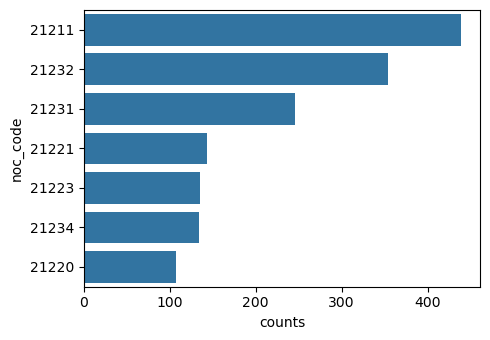

In [39]:
plt.figure(figsize=(5,3.5))
sns.barplot(data=noc_counts, x="counts", y="noc_code")
plt.tight_layout()
plt.show()

## 2. Identifying "Constant" Columns in StatCan
StatCan tables often include columns like "Geography" or "UOM" (Unit of Measure) that contain the same value for every single row in your specific pull. We want to identify these so we can drop them in the Silver layer.

In [13]:
def profile_table(con, table_name):
    df = con.execute(f"SELECT * FROM bronze.{table_name} LIMIT 1000;").df()
    # Find columns where all values are the same
    constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
    print(f"--- Profiling {table_name} ---")
    print(f"Total Columns: {len(df.columns)}")
    print(f"Constant Columns: {constant_cols}")

In [14]:
with duckdb.connect(db_path) as con:
    for t_name in db_tables["table_name"].tolist():
        profile_table(con, t_name)
        print()

--- Profiling annual_graduates_raw ---
Total Columns: 10
Constant Columns: ['Geography', 'Institution type', 'Gender', 'pid', 'ingested_at', 'source']

--- Profiling annual_labour_force_raw ---
Total Columns: 9
Constant Columns: ['Geography', 'National Occupational Classification (NOC)', 'Gender', 'pid', 'ingested_at', 'source']

--- Profiling annual_wages_raw ---
Total Columns: 11
Constant Columns: ['Geography', 'Wages', 'Type of work', 'National Occupational Classification (NOC)', 'Gender', 'Age group', 'pid', 'ingested_at', 'source']

--- Profiling census_income_2021_raw ---
Total Columns: 13
Constant Columns: ['Geography', 'Gender (3)', 'Age (4)', 'Major field of study - Classification of Instructional Programs (CIP) 2021 (63)', 'Work activity during the reference year (4A)', 'Employment income statistics (7)', 'REF_DATE', 'pid', 'ingested_at', 'source']

--- Profiling census_labour_force_2021_raw ---
Total Columns: 11
Constant Columns: ['Geography', 'Age (15A)', 'Gender (3)', 'REF

## 3. Data Transformations

In [96]:
def transform_table(con, table_name, pivot_cols=None, val_col="VALUE", keeps=["ingested_at", "source"], limit=None):
    df = con.execute(f"SELECT * FROM bronze.{table_name}" + (f" LIMIT {limit}" if limit else "") + ";").df()
    constant_cols = [col for col in df.columns if df[col].nunique() <= 1 and col not in keeps]
    df = df.drop(columns=constant_cols)

    if pivot_cols:
        pivot_idx = [c for c in df.columns if c not in pivot_cols and c != val_col]
        df_wide = df.pivot(index=pivot_idx, columns=pivot_cols, values=val_col).reset_index()
        df_wide.columns.name = None
        return df_wide
    return df

### Graduates Time-Series

In [48]:
def preprocess_graduates(data_limit):
    with duckdb.connect(db_path) as con:
        df = transform_table(con, table_name="annual_graduates_raw", keeps=["Geography"], limit=data_limit)
        df = df.rename(columns={
            "International Standard Classification of Education (ISCED)": "education_level",
            "Field of study": "field_of_study",
            "REF_DATE": "date",
            "VALUE": "graduates"
        })
        df = df.replace({
            "Bachelor's or equivalent": "Bachelor's degree",
            "Master's or equivalent": "Master's degree",
            "Doctoral or equivalent": "Doctoral degree",
            "Computer and information sciences and support services": "Computer science"
        })
        return df

In [50]:
grad_df = preprocess_graduates(data_limit=None)
grad_df.head()

,Geography,education_level,field_of_study,date,graduates
0,Canada,Bachelor's degree,Computer science,2019-01-01,6399.0
1,Canada,Bachelor's degree,Computer science,2020-01-01,7269.0
2,Canada,Bachelor's degree,Computer science,2021-01-01,8637.0
3,Canada,Bachelor's degree,Computer science,2022-01-01,9351.0
4,Canada,Bachelor's degree,Computer science,2023-01-01,10368.0


### 2021 Census Annual Income Snapshot

In [55]:
def preprocess_census_income(data_limit):
    with duckdb.connect(db_path) as con:
        keeps = [
            "Geography", "REF_DATE", "Highest certificate, diploma or degree (16)",
            "Occupation - Unit group - National Occupational Classification (NOC) 2021 (821A)"
        ]
        
        df = transform_table(con, table_name="census_income_2021_raw", keeps=keeps, limit=data_limit)
        df = df.rename(columns={
            "Occupation - Unit group - National Occupational Classification (NOC) 2021 (821A)": "occupation",
            "Highest certificate, diploma or degree (16)": "education_level",
            "REF_DATE": "date",
            "VALUE": "median_income"
        })
        df = df.replace({
            "College, CEGEP or other non-university certificate or diploma": "CEGEP/College",
            "Earned doctorate": "Doctoral degree"
        })
        df["occupation"] = df["occupation"].str.replace(r"^\d+ ", "", regex=True)
        return df

In [58]:
census_income = preprocess_census_income(data_limit=None)
census_income.head()

,Geography,education_level,occupation,date,median_income
0,Canada,Bachelor's degree,Professional occupations in applied sciences (...,2021-01-01,86000.0
1,Canada,Bachelor's degree,Data scientists,2021-01-01,87000.0
2,Canada,Bachelor's degree,Cybersecurity specialists,2021-01-01,92000.0
3,Canada,Bachelor's degree,Business systems specialists,2021-01-01,84000.0
4,Canada,Bachelor's degree,Information systems specialists,2021-01-01,88000.0


### Weekly Wages Time-Series

In [64]:
def preprocess_income_ts(data_limit):
    with duckdb.connect(db_path) as con:
        keeps = ["Geography", "REF_DATE", "National Occupational Classification (NOC)"]
        
        df = transform_table(con, table_name="annual_wages_raw", keeps=keeps, limit=data_limit)
        
        df = df.rename(columns={
            "National Occupational Classification (NOC)": "occupation",
            "REF_DATE": "date",
            "VALUE": "weekly_wages"
        })

        df["median_income"] = df["weekly_wages"] * 4 * 12

        df["occupation"] = df["occupation"].str.replace(r"^\d+ ", "", regex=True)
        return df

In [63]:
annual_income = preprocess_income_ts(data_limit=None)
annual_income.head()

,Geography,occupation,date,weekly_wages,median_income
0,Canada,Professional occupations in applied sciences (...,2021-01-01,1634.63,78462.24
1,Canada,Professional occupations in applied sciences (...,2022-01-01,1730.75,83076.00
2,Canada,Professional occupations in applied sciences (...,2023-01-01,1778.80,85382.40
3,Canada,Professional occupations in applied sciences (...,2024-01-01,1827.01,87696.48
4,Canada,Professional occupations in applied sciences (...,2025-01-01,1923.20,92313.60


### 2021 Census LFS Snapshot

In [97]:
def preprocess_census_lfs(data_limit):
    with duckdb.connect(db_path) as con:
        pivot_cols = ["Labour force status (3)"]
        keeps = [
            "Geography", "REF_DATE", "Highest certificate, diploma or degree (16)",
            "Occupation - Unit group - National Occupational Classification (NOC) 2021 (821A)"
        ]
        
        df = transform_table(
            con, 
            table_name="census_labour_force_2021_raw", 
            pivot_cols=pivot_cols, 
            keeps=keeps, 
            limit=data_limit
        )
        df = df.rename(columns={
            "Occupation - Unit group - National Occupational Classification (NOC) 2021 (821A)": "occupation",
            "Highest certificate, diploma or degree (16)": "education_level",
            "Total - Labour force status": "labour_force",
            "Employed": "employed",
            "Unemployed": "unemployed",
            "REF_DATE": "date"
        })
        df = df.replace({
            "College, CEGEP or other non-university certificate or diploma": "CEGEP/College",
            "Earned doctorate": "Doctoral degree"
        })
        df["occupation"] = df["occupation"].str.replace(r"^\d+ ", "", regex=True)
        return df

In [98]:
census_lfs = preprocess_census_lfs(data_limit=None)
census_lfs.head()

,Geography,education_level,occupation,date,employed,labour_force,unemployed
0,Canada,Bachelor's degree,Professional occupations in applied sciences (...,2021-01-01,242470.0,250425.0,7955.0
1,Canada,Bachelor's degree,Data scientists,2021-01-01,4565.0,4750.0,190.0
2,Canada,Bachelor's degree,Cybersecurity specialists,2021-01-01,5050.0,5150.0,100.0
3,Canada,Bachelor's degree,Business systems specialists,2021-01-01,13955.0,14455.0,500.0
4,Canada,Bachelor's degree,Information systems specialists,2021-01-01,55400.0,56995.0,1590.0


### LFS Time-Series

In [106]:
def preprocess_lfs_ts(data_limit):
    with duckdb.connect(db_path) as con:
        pivot_cols = ["Labour force characteristics"]
        keeps = ["Geography", "REF_DATE", "National Occupational Classification (NOC)"]
        
        df = transform_table(
            con, 
            table_name="annual_labour_force_raw",
            pivot_cols=pivot_cols,
            keeps=keeps, 
            limit=data_limit
        )
        
        df = df.rename(columns={
            "National Occupational Classification (NOC)": "occupation",
            "Labour force": "labour_force",
            "Unemployment rate": "unemployment_rate",
            "Proportion of employment": "employed",
            "REF_DATE": "date",
            "VALUE": "weekly_wages"
        })

        df["occupation"] = df["occupation"].str.replace(r"^\d+ ", "", regex=True)

        df["labour_force"] *= 1000

        df = df.drop(columns=["employed"])
        
        return df

In [107]:
annual_lfs = preprocess_lfs_ts(data_limit=None)
annual_lfs.head()

,Geography,occupation,date,labour_force,unemployment_rate
0,Canada,Professional occupations in applied sciences (...,2021-01-01,781800.0,1.7
1,Canada,Professional occupations in applied sciences (...,2022-01-01,843600.0,1.8
2,Canada,Professional occupations in applied sciences (...,2023-01-01,838600.0,2.2
3,Canada,Professional occupations in applied sciences (...,2024-01-01,884200.0,3.3
4,Canada,Professional occupations in applied sciences (...,2025-01-01,913800.0,3.3


## 4. Job Market Density Map
We need to see if we have enough "Job Posting" samples for each NOC Code to make meaningful skill extractions.

In [4]:
with duckdb.connect(db_path) as con:
    print(con.execute("""
        SELECT
            COUNT(*) - COUNT(DISTINCT job_hash) as duplicates
        FROM bronze.job_postings_raw;
    """).df())

   duplicates
0           0


In [7]:
with duckdb.connect(db_path) as con:
    posting_counts = con.execute("""
        SELECT
            noc_code,
            search_term,
            COUNT(*) as posting_count,
            COUNT(DISTINCT company) as unique_companies
        FROM bronze.job_postings_raw
        GROUP BY 1, 2
        ORDER BY posting_count DESC;
    """).df()

In [8]:
print(
    posting_counts.groupby("noc_code", as_index=False)
    .agg({"posting_count": "sum", "unique_companies": "sum"})
    .sort_values(by=["posting_count"], ascending=False)
)

  noc_code  posting_count  unique_companies
0    21211             97                75


In [9]:
posting_counts

,noc_code,search_term,posting_count,unique_companies
0,21211,"""Data Scientist""",97,75


In [11]:
with duckdb.connect(db_path) as con:
    print(con.execute("""
        SELECT
            MIN(LENGTH(description)) as min_text_length,
            AVG(LENGTH(description)) as avg_text_length,
            MAX(LENGTH(description)) as max_text_length
        FROM bronze.job_postings_raw;
    """).df().round(2))

   min_text_length  avg_text_length  max_text_length
0              500          5277.95            14991
